In [1]:
import datetime
from dateutil.relativedelta import relativedelta
import time
import json
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from castlib.cast import Cast
from castlib.reporter import Reporter
from castlib.prop import Prop
from castlib.event import Event
from castlib.stock import StockGrant
from castlib.util import format_currency

import pandas as pd
import yfinance as yf

# Shared Cost Calculation

In [2]:
d = datetime.date

shared_monthly_events = [
    Event(name="Rent", amount=-4750, date=d(2020, 2, 1)),
    Event(name="Utils", amount=-200, date=d(2020, 2, 15)),
    Event(name="Progressive", amount=-290, date=d(2020, 2, 18)),
    Event(name="Sprint", amount=-300, date=d(2020, 6, 1)),
    Event(name="Food/Cons.", amount=-600, date=d(2020, 2, 2)),
    Event(name="Carmax", amount=-910, date=d(2020, 2, 18), end=d(2022, 1, 1)),
    Event(name="Gas", amount=-200, date=d(2020, 2, 2))
]

# == CONFIG ==
# cost for healthcare
healthcare = 150
# rebecca's max expeses
rebecca_target = 0

total_split_cost = healthcare + 0
exp = []
# halve each shared event and supply a total for rebecca
for event in shared_monthly_events:
    event.amount /= 2
    exp.append([event.name, abs(event.amount)])
    total_split_cost += abs(event.amount)

if total_split_cost > rebecca_target:
    overage = total_split_cost - rebecca_target
    shared_monthly_events.append(Event(name="Rebecca Overage", amount=-overage, date=d(2020,1,1)))
    print(f"Overage amount: {format_currency(overage)}")
    print(f"Total paid: {format_currency(rebecca_target)}")
else:
    print(f"Total monthly balance for Rebecca: {format_currency(total_split_cost)}")
    

pd.DataFrame(exp)

Overage amount: $3,775
Total paid: $0


,0,1
0,Rent,2375.0
1,Utils,100.0
2,Progressive,145.0
3,Sprint,150.0
4,Food/Cons.,300.0
5,Carmax,455.0
6,Gas,100.0


# Stock Comp Calculation

In [3]:
stock_grant = StockGrant(ticker='NVDA', total_shares=685, date=d(2021, 12, 8))
stock_grant.end = d(3000, 1, 1)
stock_grant

Yearly RSU grant is currently worth: $89,427
NVDA is currently worth $522

First day over $1mm: 2027-08-15


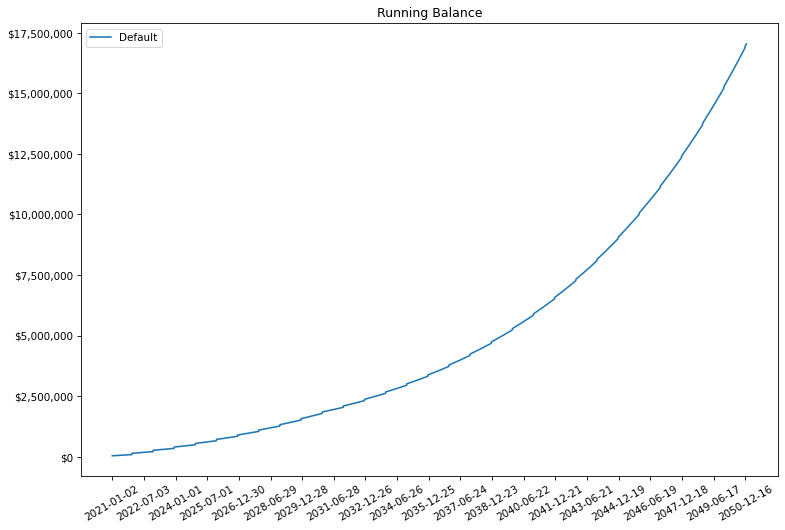

In [4]:
# config
monthly_spending_money = 0
monthly_401k = 300 * 2 * 2
monthly_ESPP = 300 / 0.85
# mint PF
personal_capital = 41625.86

c = (Cast(balance=personal_capital, start=d.today())
    .end_after(years=30)
    .report_with(Reporter)
    .set_min_cash(1000)
    .at_apr(10)
     
    .add_event(Event(name="NVIDIA Post-Tax Salary", amount=4826, date=d(2020, 11, 1)).monthly)
    .add_event(Event(name="NVIDIA Post-Tax Salary", amount=4826, date=d(2020, 11, 15)).monthly)
    .add_event(Event(name="Addtl. Savings", amount=monthly_401k + monthly_ESPP, date=d(2020, 1, 1)).monthly)
    .add_event(Event(name="Spending Money", amount=-(monthly_spending_money/4), date=d(2020, 1, 1)).weekly)
    .add_event(stock_grant.yearly)
)

# add all monthly events in shared set
for event in shared_monthly_events:
    c.add_event(event.monthly)
c.save(f"/Users/jacobsansbury/Casts/NVIDIA-{d.today()}.json")   

c.report.running_balance();
print(f"First day over $1mm: {str(c.first_day_over(1e6))}")

In [7]:
milestones = c.report.milestones()

In [12]:
milestones[:11].to_clipboard()